# **SVM Model Traning - IT24101977 - Hettiarachchi C.K**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Load and Prepare the Data**

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.246298  0.070528 -0.222638  1.376894 -1.232092 -0.398827 -2.265409   
1 -2.436325  0.896890 -1.330149 -0.737714  0.988988 -0.153911 -0.358441   
2 -2.073777 -0.348400  0.653504  0.994999  1.053923  1.748551 -0.400117   
3  0.866853  1.735698 -1.016299  0.261916 -0.475206 -0.642468  0.351777   
4 -1.038775  1.239293 -0.310488 -0.000741  0.112410 -1.259492 -2.120972   

        PC8  Depression  
0  0.260950           1  
1 -0.432141           0  
2 -1.123719           0  
3  1.188882           1  
4  0.466045           0  

Missing values:
 PC1           0
PC2           0
PC3           0
PC4           0
PC5           0
PC6           0
PC7           0
PC8           0
Depression    0
dtype: int64
=== SVM Model - Detailed Evaluation ===
Accuracy: 0.8491
Precision: 0.8488
Recall: 0.8491
F1-Score: 0.8483

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84  

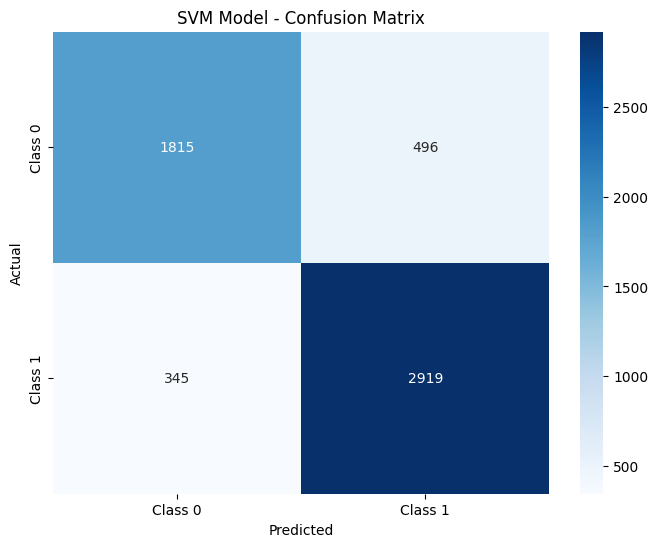


=== Per-Class Metrics ===
Class 0: Precision=0.8403, Recall=0.7854, F1-Score=0.8119
Class 1: Precision=0.8548, Recall=0.8943, F1-Score=0.8741


In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML_Project/rfe_pca_df.csv")
print(df.head())

# Check Missing Values ---
print("\nMissing values:\n", df.isnull().sum())

# Separate Features and Target
target_column = 'Depression'
X = df.drop(columns=[target_column])
y = df[target_column]

# Encode Target if Categorical
if y.dtypes == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Target column encoded successfully.")

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Basic SVM Model
best_svm_model = SVC(kernel='rbf', C=500, gamma=0.0005, random_state=42)
best_svm_model.fit(X_train, y_train)

# Predictions
y_pred = best_svm_model.predict(X_test)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print("=== SVM Model - Detailed Evaluation ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('SVM Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Per-class metrics
print("\n=== Per-Class Metrics ===")
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

for i, (prec, rec, f1_sc) in enumerate(zip(precision_per_class, recall_per_class, f1_per_class)):
    print(f"Class {i}: Precision={prec:.4f}, Recall={rec:.4f}, F1-Score={f1_sc:.4f}")

# **Manual tuning**

=== Manual Parameter Exploration with Full Metrics ===

C=100, Gamma=0.01 -> Accuracy: 0.8427, Precision: 0.8421, Recall: 0.8427, F1-Score: 0.8420
C=100, Gamma=0.001 -> Accuracy: 0.8488, Precision: 0.8484, Recall: 0.8488, F1-Score: 0.8480
C=100, Gamma=0.0005 -> Accuracy: 0.8474, Precision: 0.8469, Recall: 0.8474, F1-Score: 0.8467
C=500, Gamma=0.01 -> Accuracy: 0.8436, Precision: 0.8430, Recall: 0.8436, F1-Score: 0.8429
C=500, Gamma=0.001 -> Accuracy: 0.8481, Precision: 0.8483, Recall: 0.8481, F1-Score: 0.8467
C=500, Gamma=0.0005 -> Accuracy: 0.8491, Precision: 0.8488, Recall: 0.8491, F1-Score: 0.8483
C=1000, Gamma=0.01 -> Accuracy: 0.8441, Precision: 0.8436, Recall: 0.8441, F1-Score: 0.8434
C=1000, Gamma=0.001 -> Accuracy: 0.8483, Precision: 0.8486, Recall: 0.8483, F1-Score: 0.8468
C=1000, Gamma=0.0005 -> Accuracy: 0.8491, Precision: 0.8490, Recall: 0.8491, F1-Score: 0.8481
C=1200, Gamma=0.01 -> Accuracy: 0.8445, Precision: 0.8440, Recall: 0.8445, F1-Score: 0.8438
C=1200, Gamma=0.001 -

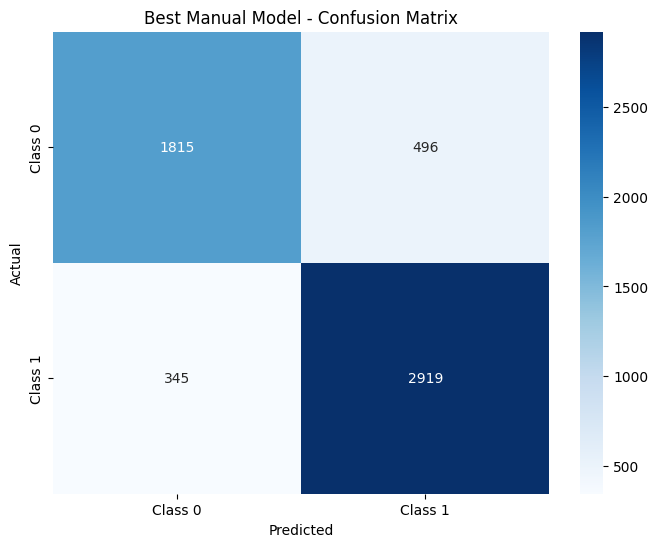

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Parameter values for manual exploration
C_values = [100, 500, 1000, 1200, 1500]
gamma_values = [0.01, 0.001, 0.0005]
kernel_type = 'rbf'

best_manual_acc = 0
best_manual_params = {}
best_manual_model = None
manual_results = []

print("=== Manual Parameter Exploration with Full Metrics ===\n")

for C in C_values:
    for gamma in gamma_values:
        # Create and train model
        model = SVC(kernel=kernel_type, C=C, gamma=gamma, random_state=42)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Calculate all metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Store results
        result = {
            'C': C,
            'gamma': gamma,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }
        manual_results.append(result)

        print(f"C={C}, Gamma={gamma} -> "
              f"Accuracy: {accuracy:.4f}, "
              f"Precision: {precision:.4f}, "
              f"Recall: {recall:.4f}, "
              f"F1-Score: {f1:.4f}")

        # Update best model
        if accuracy > best_manual_acc:
            best_manual_acc = accuracy
            best_manual_params = {'C': C, 'gamma': gamma}
            best_manual_model = model

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(manual_results)
print("\n=== Manual Exploration Results Summary ===")
print(results_df.round(4))

print(f"\n=== Best Manual Model Found ===")
print(f"Best Parameters: C={best_manual_params['C']}, Gamma={best_manual_params['gamma']}")
print(f"Best Accuracy: {best_manual_acc:.4f}")

# Detailed evaluation of best manual model
y_pred_best_manual = best_manual_model.predict(X_test)

best_manual_accuracy = accuracy_score(y_test, y_pred_best_manual)
best_manual_precision = precision_score(y_test, y_pred_best_manual, average='weighted')
best_manual_recall = recall_score(y_test, y_pred_best_manual, average='weighted')
best_manual_f1 = f1_score(y_test, y_pred_best_manual, average='weighted')

print(f"\n=== Best Manual Model Detailed Evaluation ===")
print(f"Accuracy: {best_manual_accuracy:.4f}")
print(f"Precision: {best_manual_precision:.4f}")
print(f"Recall: {best_manual_recall:.4f}")
print(f"F1-Score: {best_manual_f1:.4f}")

print("\n=== Classification Report for Best Manual Model ===")
print(classification_report(y_test, y_pred_best_manual))

# Confusion Matrix for best manual model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_manual = confusion_matrix(y_test, y_pred_best_manual)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_manual, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Best Manual Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()